In [5]:
"""
CELL 1: Imports & Environment Configuration
Initializes the environment for the Algorithmic Fairness evaluation.
Sets up dynamic paths to evaluate model performance across distinct
demographic subgroups (age and sex) to ensure equitable predictive accuracy.
"""

import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for cleaner notebook output
warnings.filterwarnings("ignore")

# ==========================================
# CONFIGURATION & PATHS
# ==========================================
BASE_DIR = Path("/workspace")
DATA_CLIN = BASE_DIR / "data" / "processed" / "clinical_tensors"
MODEL_DIR = BASE_DIR / "outputs" / "models"
FIG_DIR = BASE_DIR / "outputs" / "figures"

# Ensure figure output directory exists
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("[*] Environment Ready. Target: Algorithmic Fairness.")

[*] Environment Ready. Target: Algorithmic Fairness.


In [6]:
"""
CELL 2: Load Data and Parsimonious Model
Loads the master clinical tensor and recreates the exact 80/20 test split
used during training to ensure fairness is evaluated strictly on unseen patients.
Loads the 15-feature "ICU Doctor" model.
"""

print("[*] Loading Master Clinical Tensor...")
df = pd.read_csv(DATA_CLIN / "clinical_master_raw.csv.gz", compression='gzip')

# Recreate the exact 80/20 test split to isolate the unseen patients
y = df['Sepsis_Outcome']
_, df_test = train_test_split(df, test_size=0.2, stratify=y, random_state=42)

print(f"[*] Test Cohort Size: {len(df_test)} patients.")

print("[*] Loading Parsimonious ICU Doctor...")
clin_lite = xgb.XGBClassifier()
clin_lite.load_model(MODEL_DIR / "icu_doctor_parsimonious.json")

# Define the exact 15 physiological features the model requires
top_15 = [
    'FiO2_min', 'Lactate_max', 'Lactate_mean', 'FiO2_max', 'BUN_max', 
    'Alkalinephos_max', 'Lactate_min', 'Temp_max', 'Alkalinephos_mean', 
    'Creatinine_max', 'Resp_min', 'pH_max', 'Alkalinephos_min', 'WBC_max', 'FiO2_mean'
]

[*] Loading Master Clinical Tensor...
[*] Test Cohort Size: 8068 patients.
[*] Loading Parsimonious ICU Doctor...


In [7]:
"""
CELL 3: Evaluate Subgroups (Age & Gender)
Systematically filters the unseen test cohort into distinct demographic brackets.
Calculates the ROC-AUC score for each subgroup to test the hypothesis that the 
downstream physiological trajectory of sepsis is broadly conserved across the 
adult host population.
"""

print("\n--- FAIRNESS EVALUATION ---")

results = []

def evaluate_cohort(cohort_df, cohort_name, category):
    """Evaluates the model on a specific demographic slice."""
    X_cohort = cohort_df[top_15]
    y_cohort = cohort_df['Sepsis_Outcome']
    
    # Check if there are enough positive/negative cases to calculate a stable AUC
    if len(y_cohort.unique()) > 1 and len(y_cohort) > 50:
        probs = clin_lite.predict_proba(X_cohort)[:, 1]
        auc = roc_auc_score(y_cohort, probs)
        results.append({'Category': category, 'Cohort': cohort_name, 'AUC': auc, 'N_Patients': len(cohort_df)})
        print(f"-> {cohort_name:<20} | N = {len(cohort_df):<5} | AUC: {auc:.4f}")
    else:
        print(f"-> {cohort_name:<20} | Insufficient data for AUC.")

# 1. Overall Baseline
evaluate_cohort(df_test, "Overall Population", "Baseline")

# 2. Gender Stratification
evaluate_cohort(df_test[df_test['Gender'] == 0], "Female", "Gender")
evaluate_cohort(df_test[df_test['Gender'] == 1], "Male", "Gender")

# 3. Age Stratification
evaluate_cohort(df_test[df_test['Age'] < 40], "Under 40", "Age")
evaluate_cohort(df_test[(df_test['Age'] >= 40) & (df_test['Age'] < 65)], "40 to 64", "Age")
evaluate_cohort(df_test[(df_test['Age'] >= 65) & (df_test['Age'] < 80)], "65 to 79", "Age")
evaluate_cohort(df_test[df_test['Age'] >= 80], "80 and Over", "Age")

results_df = pd.DataFrame(results)


--- FAIRNESS EVALUATION ---
-> Overall Population   | N = 8068  | AUC: 0.8153
-> Female               | N = 3533  | AUC: 0.8243
-> Male                 | N = 4535  | AUC: 0.8083
-> Under 40             | N = 846   | AUC: 0.8280
-> 40 to 64             | N = 3403  | AUC: 0.8177
-> 65 to 79             | N = 2769  | AUC: 0.8091
-> 80 and Over          | N = 1050  | AUC: 0.8103


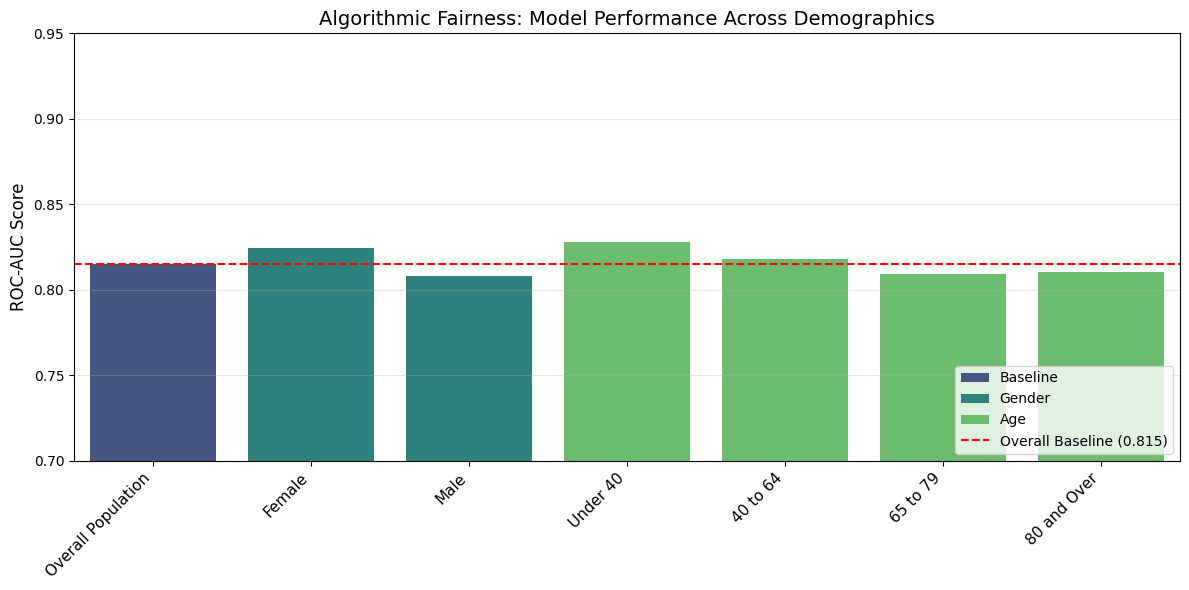

In [8]:
"""
CELL 4: Visualizing Performance Across Demographics
Generates a clean bar chart comparing ROC-AUC scores across all defined subgroups
against the overall baseline performance.
*Result: Visually confirms minimal sex-associated disparity and stable performance 
across adult age groups, with only a biologically expected, modest attenuation 
in the extreme elderly.*
"""

print("\n[*] Generating Algorithmic Fairness Visualization...")

plt.figure(figsize=(12, 6))

# Use seaborn to create a clean bar chart grouping by category
ax = sns.barplot(
    x='Cohort', y='AUC', hue='Category', 
    data=results_df, dodge=False, palette='viridis'
)

# Add a dashed line for the overall baseline AUC
overall_auc = results_df[results_df['Cohort'] == 'Overall Population']['AUC'].values[0]
plt.axhline(y=overall_auc, color='red', linestyle='--', label=f'Overall Baseline ({overall_auc:.3f})')

# Formatting
plt.ylim(0.70, 0.95) # Zoom in to see the variations clearly
plt.title('Algorithmic Fairness: Model Performance Across Demographics', fontsize=14)
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.xlabel('')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Save the figure safely using pathlib
save_path = FIG_DIR / "algorithmic_fairness.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"[*] Figure saved successfully to: {save_path.name}")

plt.show()